In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.sparse import issparse
from scipy.special import rel_entr

from pyscf import gto, scf, fci
from qiskit.quantum_info import SparsePauliOp, Statevector, state_fidelity
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import ADAM, COBYLA, SPSA
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import FreezeCoreTransformer
from qiskit_nature.second_q.circuit.library import HartreeFock

In [ ]:
MOLECULE = "H4"
BASIS = "sto-3g"
R = 0.96  

GEOM = f"H 0 0 0; H 0 0 {R}; H {R} 0 0; H {R} 0 {R}"

mol = gto.M(atom=GEOM, basis=BASIS, unit="Angstrom")
mf = scf.RHF(mol).run(verbose=0)
E_HF, E_FCI = mf.e_tot, fci.FCI(mf).kernel()[0]

print(f"{MOLECULE}/{BASIS} R={R}")
print(f"E_HF  = {E_HF:.6f} Ha")
print(f"E_FCI = {E_FCI:.6f} Ha")
print(f"Corr  = {(E_FCI-E_HF)*1000:.2f} mHa")

H2/sto-3g R=0.96
E_HF  = -1.077020 Ha
E_FCI = -1.109367 Ha
Corr  = -32.35 mHa


In [ ]:
problem = PySCFDriver(atom=GEOM, basis=BASIS, unit=DistanceUnit.ANGSTROM).run()
prob_fc = FreezeCoreTransformer().transform(problem)
mapper = prob_fc.get_tapered_mapper(mapper=JordanWignerMapper())

qop = mapper.map(prob_fc.hamiltonian.second_q_op())
enuc = prob_fc.hamiltonian.nuclear_repulsion_energy
hf_circuit = HartreeFock(prob_fc.num_spatial_orbitals, prob_fc.num_particles, mapper)
e_off = problem.reference_energy - float(np.real(Statevector(hf_circuit).expectation_value(qop))) - enuc

n_sys = qop.num_qubits
print(f"Original Qubbits: {problem.num_spin_orbitals}, Terms: {len(prob_fc.hamiltonian.second_q_op())}")
print(f"Qubits: {n_sys}, Terms: {len(qop)}")

Original Qubbits: 4, Terms: 36
Qubits: 1, Terms: 3


In [5]:
problem = PySCFDriver(atom=GEOM, basis=BASIS, unit=DistanceUnit.ANGSTROM).run()
prob_fc = FreezeCoreTransformer().transform(problem)

print("FULL")
print("  num_spin_orbitals :", problem.num_spin_orbitals)
print("  num_particles     :", problem.num_particles)

print("FREEZE-CORE")
print("  num_spin_orbitals :", prob_fc.num_spin_orbitals)
print("  num_particles     :", prob_fc.num_particles)

# no tapering
mapper_jw = JordanWignerMapper()
qop_jw = mapper_jw.map(prob_fc.hamiltonian.second_q_op())

print("JW NO TAPER")
print("  qop.num_qubits    :", qop_jw.num_qubits)
print("  len(qop_jw)       :", len(qop_jw))

# tapered
mapper_taper = prob_fc.get_tapered_mapper(mapper=JordanWignerMapper())
qop_taper = mapper_taper.map(prob_fc.hamiltonian.second_q_op())

print("JW TAPERED")
print("  qop.num_qubits    :", qop_taper.num_qubits)
print("  len(qop_taper)    :", len(qop_taper))

FULL
  num_spin_orbitals : 4
  num_particles     : (1, 1)
FREEZE-CORE
  num_spin_orbitals : 4
  num_particles     : (1, 1)
JW NO TAPER
  qop.num_qubits    : 4
  len(qop_jw)       : 15
JW TAPERED
  qop.num_qubits    : 1
  len(qop_taper)    : 3


In [86]:
def build_haa(n_sys, n_anc, n_layers, hf_circuit=None):
    n_params = 3 * (n_sys + n_anc) * (n_layers + 1) + 3 * n_sys * n_anc * n_layers
    p = ParameterVector('t', n_params)
    qc = QuantumCircuit(n_sys + n_anc)
    if hf_circuit:
        qc.compose(hf_circuit, qubits=range(n_sys), inplace=True)
    i = 0

    # Initial local block on system + ancilla qubits.
    for q in range(n_sys + n_anc):
        qc.u(p[i], p[i+1], p[i+2], q); i += 3

    for _ in range(n_layers):
        for a in range(n_anc):
            for s in range(n_sys):
                qc.rxx(p[i], s, n_sys+a); qc.ryy(p[i+1], s, n_sys+a); qc.rzz(p[i+2], s, n_sys+a); i += 3

        # Local block after each interaction layer.
        for q in range(n_sys + n_anc):
            qc.u(p[i], p[i+1], p[i+2], q); i += 3

    return qc

In [87]:
def build_hea(n_sys, n_layers, hf_circuit=None):
    n_params = 3 * n_sys * (n_layers + 1)
    p = ParameterVector('t', n_params)
    qc = QuantumCircuit(n_sys)
    if hf_circuit:
        qc.compose(hf_circuit, qubits=range(n_sys), inplace=True)
    i = 0
    for q in range(n_sys):
        qc.u(p[i], p[i+1], p[i+2], q); i += 3
    for _ in range(n_layers):
        for s in range(n_sys):
            qc.rx(p[i], s); qc.ry(p[i+1], s); qc.rz(p[i+2], s); i += 3
    return qc

In [88]:
def build_qrqnn(
    n_sys: int,
    n_anc: int,
    n_layers: int,
    hf_circuit: QuantumCircuit | None = None
) -> QuantumCircuit:
    total_qubits = n_sys + n_anc

    n_params = 3 * total_qubits * (n_layers + 1) + 3 * n_sys * n_anc * n_layers
    params = ParameterVector("t", n_params)

    qc = QuantumCircuit(total_qubits, name="QRQNN")

    if hf_circuit is not None:
        if hf_circuit.num_qubits != n_sys:
            raise ValueError("hf_circuit harus punya jumlah qubit sama dengan n_sys")
        qc.compose(hf_circuit, qubits=range(n_sys), inplace=True)

    idx = 0

    # input local block (system + ancilla)
    for q in range(total_qubits):
        qc.u(params[idx], params[idx + 1], params[idx + 2], q)
        idx += 3

    for _ in range(n_layers):
        # system ring entanglement (non-trainable, gives QRQNN structure)
        if n_sys > 1:
            for q in range(n_sys - 1):
                qc.cx(q, q + 1)
            qc.cx(n_sys - 1, 0)

        # trainable system-ancilla couplings
        for anc in range(n_anc):
            anc_q = n_sys + anc
            for sys_q in range(n_sys):
                qc.rxx(params[idx], sys_q, anc_q)
                qc.ryy(params[idx + 1], sys_q, anc_q)
                qc.rzz(params[idx + 2], sys_q, anc_q)
                idx += 3

        # local block after each layer
        for q in range(total_qubits):
            qc.u(params[idx], params[idx + 1], params[idx + 2], q)
            idx += 3

    return qc

In [89]:
from scipy.stats import entropy


def expressibility(circuit, n_samples=500, n_bins=50, eps=1e-12, seed=None):
    n_params = circuit.num_parameters
    n_qubits = circuit.num_qubits
    N = 2 ** n_qubits
    rng = np.random.default_rng(seed)

    fidelities = []

    for _ in range(n_samples):
        theta1 = rng.uniform(0, 2 * np.pi, n_params)
        theta2 = rng.uniform(0, 2 * np.pi, n_params)

        psi1 = Statevector(circuit.assign_parameters(theta1))
        psi2 = Statevector(circuit.assign_parameters(theta2))

        fidelities.append(state_fidelity(psi1, psi2))

    fidelities = np.array(fidelities)

    hist, edges = np.histogram(fidelities, bins=n_bins, range=(0, 1), density=True)
    width = edges[1] - edges[0]

    p_ansatz = hist * width

    # Exact Haar probability mass for each bin to reduce large-N binning bias.
    p_haar = (1 - edges[:-1]) ** (N - 1) - (1 - edges[1:]) ** (N - 1)

    p_ansatz = np.clip(p_ansatz, eps, None)
    p_haar = np.clip(p_haar, eps, None)

    p_ansatz /= np.sum(p_ansatz)
    p_haar /= np.sum(p_haar)

    return entropy(p_ansatz, p_haar)

In [9]:
import pandas as pd

In [90]:
layers = [i for i in range(1,7)]

layer_repeats = 10
base_seed = 1234

df_layer = []

for layer in layers:
    expr_haa_list, expr_hea_list, expr_qrqnn_list = [], [], []
    for rep in range(layer_repeats):
        haa = build_haa(n_sys, n_anc=1, n_layers=layer, hf_circuit=hf_circuit)
        hea = build_hea(n_sys, n_layers=layer, hf_circuit=hf_circuit)
        qrqnn = build_qrqnn(n_sys, n_anc=1, n_layers=layer, hf_circuit=hf_circuit)
        seed = base_seed + 100 * layer + rep
        expr_haa_list.append(expressibility(haa, n_samples=1000, n_bins=100, seed=seed))
        expr_hea_list.append(expressibility(hea, n_samples=1000, n_bins=100, seed=seed))
        expr_qrqnn_list.append(expressibility(qrqnn, n_samples=1000, n_bins=100, seed=seed))
    
    df_layer.append({
        "Layer": layer,
        "HAA": np.mean(expr_haa_list),
        "HEA": np.mean(expr_hea_list),
        "QRQNN": np.mean(expr_qrqnn_list)
    })

df_layer = pd.DataFrame(df_layer)

In [ ]:
ancillas = [i for i in range(0,7)]
ancilla_repeats = 20
base_seed = 1024

df_ancilla = []
for anc in ancillas:
    haa = build_haa(n_sys, n_anc=anc, n_layers=1, hf_circuit=hf_circuit)
    qrqnn = build_qrqnn(n_sys, n_anc=anc, n_layers=1, hf_circuit=hf_circuit)

    expr_haa_list, expr_qrqnn_list = [], []
    for rep in range(ancilla_repeats):
        seed = base_seed + 100 * anc + rep
        expr_haa_list.append(expressibility(haa, n_samples=3000, n_bins=120, seed=seed))
        expr_qrqnn_list.append(expressibility(qrqnn, n_samples=3000, n_bins=120, seed=seed))

    df_ancilla.append({
        "Ancillas": anc,
        "HAA": np.mean(expr_haa_list),
        "HAA_std": np.std(expr_haa_list),
        "QRQNN": np.mean(expr_qrqnn_list),
        "QRQNN_std": np.std(expr_qrqnn_list)
    })
df_ancilla = pd.DataFrame(df_ancilla)

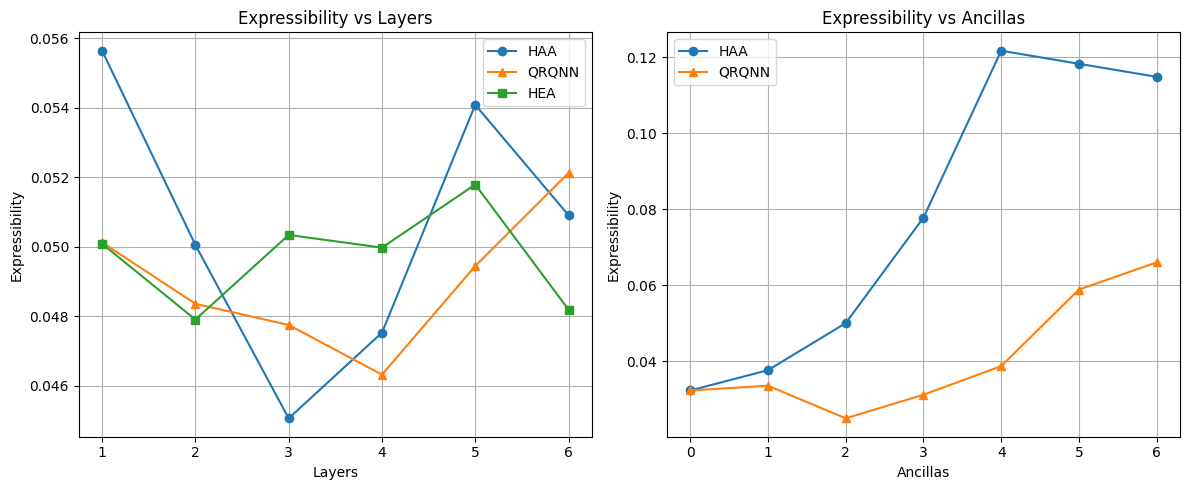

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].plot(df_layer["Layer"], df_layer["HAA"], label="HAA", marker='o')
ax[0].plot(df_layer["Layer"], df_layer["QRQNN"], label="QRQNN", marker='^')
ax[0].plot(df_layer["Layer"], df_layer["HEA"], label="HEA", marker='s')
ax[0].set_xlabel("Layers")
ax[0].set_ylabel("Expressibility (DKL)")
ax[0].set_title("Expressibility vs Layers")
ax[0].grid()
ax[0].legend()

ax[1].plot(df_ancilla["Ancillas"], df_ancilla["HAA"], label="HAA", marker='o')
ax[1].fill_between(
    df_ancilla["Ancillas"],
    df_ancilla["HAA"] - df_ancilla["HAA_std"],
    df_ancilla["HAA"] + df_ancilla["HAA_std"],
    alpha=0.2
)
ax[1].plot(df_ancilla["Ancillas"], df_ancilla["QRQNN"], label="QRQNN", marker='^')
ax[1].fill_between(
    df_ancilla["Ancillas"],
    df_ancilla["QRQNN"] - df_ancilla["QRQNN_std"],
    df_ancilla["QRQNN"] + df_ancilla["QRQNN_std"],
    alpha=0.2
)
ax[1].set_xlabel("Ancillas")
ax[1].set_ylabel("Expressibility (DKL)")
ax[1].set_title("Expressibility vs Ancillas")
ax[1].legend()
ax[1].grid()
plt.tight_layout()

In [ ]:
print(df_ancilla)
print(df_layer)

   Ancillas       HAA     QRQNN
0         0  0.029711  0.029711
1         1  0.035137  0.033536
2         2  0.055461  0.028441
3         3  0.078401  0.031285
4         4  0.114369  0.050782
5         5  0.118803  0.061426
6         6  0.131261  0.056112
   Layer       HAA       HEA     QRQNN
0      1  0.055639  0.050082  0.050121
1      2  0.050049  0.047901  0.048355
2      3  0.045058  0.050336  0.047745
3      4  0.047523  0.049972  0.046316
4      5  0.054083  0.051788  0.049442
5      6  0.050902  0.048186  0.052122


In [10]:
expressibility(build_hea(n_sys=n_sys, n_layers=3, hf_circuit=hf_circuit))

np.float64(0.233964832549937)

In [13]:
def bp_analysis(circuit, qop, n_anc, n_samples=20):
    qop_ext = SparsePauliOp.from_list([("I"*n_anc,1.0)]).tensor(qop) if n_anc else qop
    H = qop_ext.to_matrix(); H = H.toarray() if issparse(H) else H
    grads = []
    for _ in range(n_samples):
        params = np.random.uniform(0, 2*np.pi, circuit.num_parameters)
        g = []
        for i in range(min(10, circuit.num_parameters)):
            pp, pm = params.copy(), params.copy(); pp[i] += np.pi/2; pm[i] -= np.pi/2
            psip, psim = Statevector(circuit.assign_parameters(pp)).data, Statevector(circuit.assign_parameters(pm)).data
            g.append((np.real(np.vdot(psip, H@psip)) - np.real(np.vdot(psim, H@psim))) / 2)
        grads.append(g)
    return np.mean(np.abs(grads))

In [16]:
bp_analysis(build_hea(n_sys=n_sys, n_layers=3, hf_circuit=hf_circuit), qop, n_anc=0)

np.float64(0.36826246611565466)

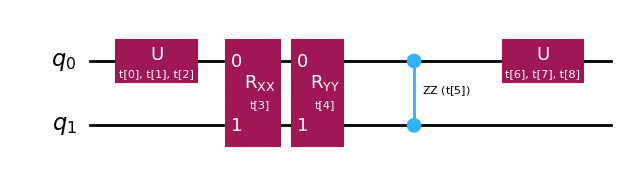

In [81]:
circuit_haa = build_haa(n_sys, n_anc=1, n_layers=1, hf_circuit=hf_circuit)
circuit_haa.draw('mpl', style='iqp')

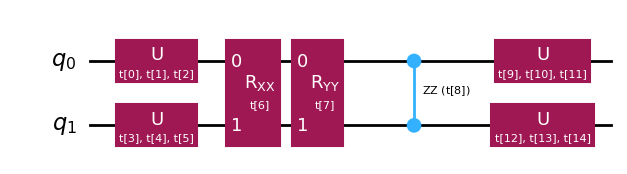

In [82]:
circuit_qrqnn = build_qrqnn(n_sys, n_anc=1, n_layers=1, hf_circuit=hf_circuit)
circuit_qrqnn.draw('mpl', style='iqp')

L=1, na=3, params=90


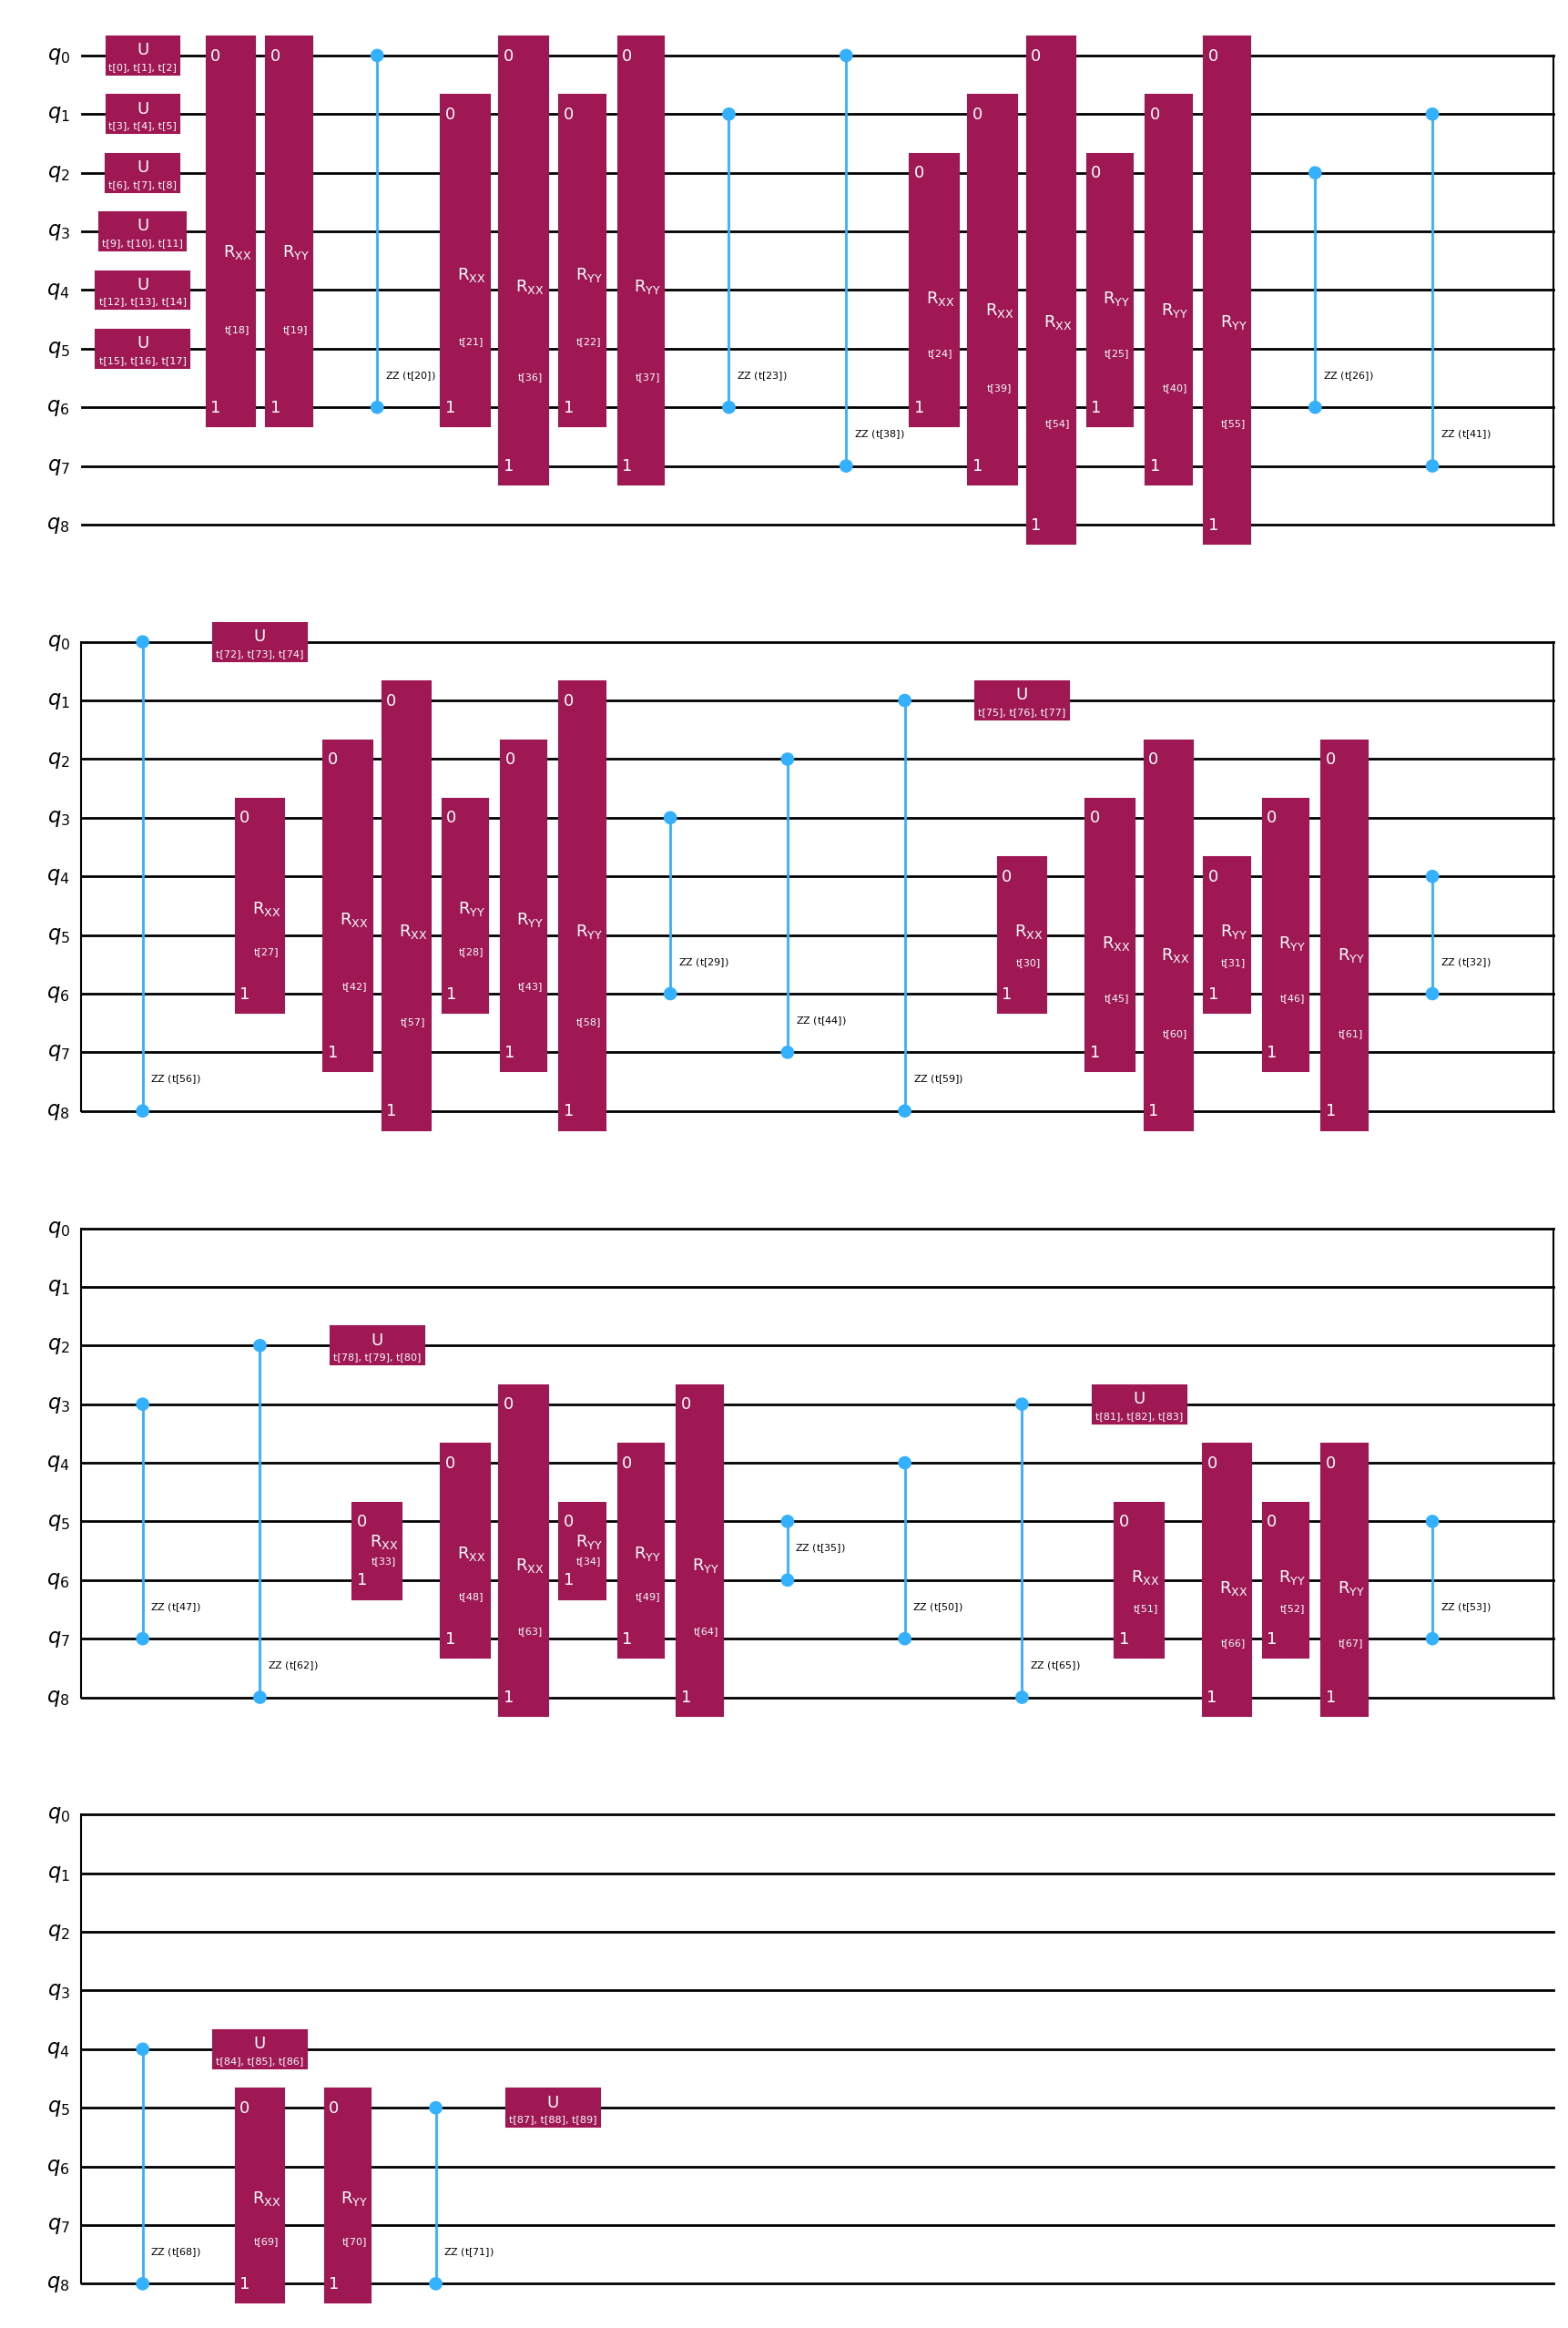

In [49]:
N_LAYERS = 1
N_ANC = 3
N_RESTARTS = 5
MAXITER = 200

circuit = build_haa(n_sys, N_ANC, N_LAYERS, hf_circuit)
print(f"L={N_LAYERS}, na={N_ANC}, params={circuit.num_parameters}")
circuit.draw('mpl', style='iqp')

In [ ]:
qop_ext = SparsePauliOp.from_list([("I"*N_ANC,1.0)]).tensor(qop) if N_ANC else qop
qop_shift = qop_ext + SparsePauliOp.from_list([("I"*qop_ext.num_qubits, enuc + e_off)])

optimizer = ADAM(maxiter=MAXITER)
# optimizer = COBYLA(maxiter=MAXITER)
# optimizer = SPSA(maxiter=MAXITER)
# optimizer = Powell(maxiter=MAXITER)

best_energy = float('inf')
for _ in range(N_RESTARTS):
    vqe = VQE(StatevectorEstimator(), circuit, optimizer,
              initial_point=np.random.uniform(-0.1, 0.1, circuit.num_parameters))
    result = vqe.compute_minimum_eigenvalue(qop_shift)
    if result.eigenvalue.real < best_energy:
        best_energy = result.eigenvalue.real
E_VQE = best_energy

In [ ]:
err = abs(E_VQE - E_FCI) * 1000
print(f"E_HF  = {E_HF:.8f} Ha")
print(f"E_FCI = {E_FCI:.8f} Ha")
print(f"E_VQE = {E_VQE:.8f} Ha")
print(f"Error = {err:.4f} mHa {'< 1.6 mHa' if err<1.6 else ''}")

E_HF  = -159.99254558 Ha
E_FCI = -160.05078336 Ha
E_VQE = -159.99641032 Ha
Error = 54.3730 mHa 


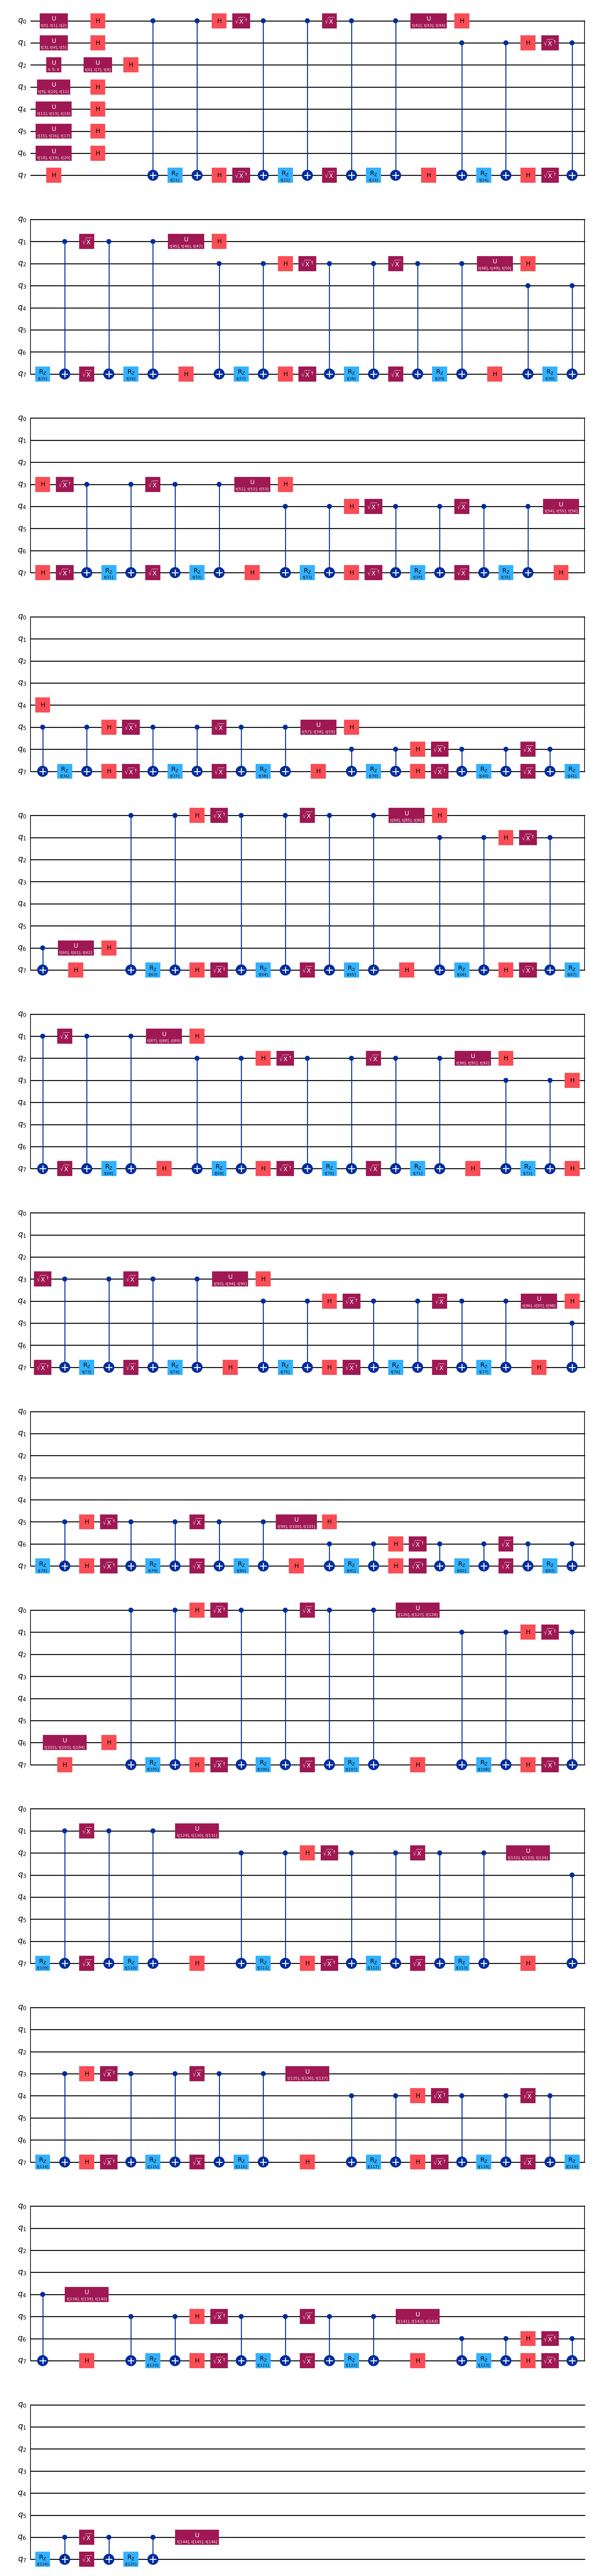

In [ ]:
circuit.decompose().draw('mpl', style='iqp')